## Introduction

The datasets used for this data story are the `Taylor_Train.csv`([link](https://www.kaggle.com/code/febinphilips/taylor-swift-concerts-analysis?select=Taylor_Train.csv)), `taylor_swift_lyrics.csv`([link](https://www.kaggle.com/datasets/PromptCloudHQ/taylor-swift-song-lyrics-from-all-the-albumsk)), and the GeoJSON file for countries in the world.

The dataset, `Taylor_Train.csv`assesses data from Taylor Swift's five tours between her *Fearless* album and *Reputation* album (there was no tour before the *Fearless* album). The dataset contains 7 columns with 445 rows. The specific variables analyzed in this dataset are:

* `Country`: The name of the country where the city is.
* `City`: The name of the city where the concert was.
* `Attendance (tickets sold / available)`: The number of tickets sold and the total number of tickets available for the concert.
* `Revenue`: The revenue generated from ticket sales during the concert.

The dataset, `taylor_swift_lyrics.csv`assesses Taylor Swift's song lyrics from her first six albums (*Taylor Swift, Fearless, Speak Now, Red, 1989, Reputation*). So, this dataset contains information comparable to the concert dataset.  The dataset contains 7 columns with 4862 rows. The specific variables analyzed in this project are:

* `album`: The name of the album.
* `lyric`: The lyrics in the song.

These descriptions can be found at the kaggle sources above. These datasets and variables guided the following research questions.

## Research Questions

Questions 1-3 assess the distributions of the variables `Revenue` and `attendance_sold`. Questions 4-5 use machine learning and NLP analysis to compare the variables `lyrics` and `albums`:

1. Is there a linear relationship between Taylor Swift concert ticket sales and their revenue?
2. How is Taylor Swift's concert ticket revenue distributed across cities in the United States? How are ticket sales distributed?
3. How is Taylor Swift's concert ticket revenue distributed across countries? How are ticket sales distributed?
4. Which 3-word lyrical phrases most strongly distinguish Taylor Swift albums from one another?
5. What words characterize the identity of lyrics of Fearless versus Red?

## Importing and Cleaning Data

The following packages were imported to conduct the specific analyses for the research questions. 

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import geopandas as gpd
import folium
import json, plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio 
import matplotlib.pyplot as plt
from shapely.geometry import Point

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from wordcloud import WordCloud
from jupyter_compare_view import compare
from PIL import Image
from sklearn.model_selection import train_test_split
sns.set_theme()

import plotly.io as pio 

pio.renderers.default = 'plotly_mimetype+notebook_connected'

import warnings
warnings.filterwarnings("ignore")

`Taylor_Train.csv` was read through and assigned to the dataframe `concert`

In [185]:
concert = pd.read_csv("Taylor_Train.csv", encoding='cp1252')
concert.head()

,City,Country,Venue,Opening act(s),Attendance (tickets sold / available),Revenue,Tour
0,Evansville,United States,Roberts Municipal Stadium,Gloriana\r\nKellie Pickler,"7,463 / 7,463","$360,617",Fearless_Tour
1,Jonesboro,United States,Convocation Center,Gloriana\r\nKellie Pickler,"7,822 / 7,822","$340,328",Fearless_Tour
2,St. Louis,United States,Scottrade Center,Gloriana\r\nKellie Pickler,"13,764 / 13,764","$650,420",Fearless_Tour
3,Alexandria,United States,Bishop Ireton High School,Gloriana\r\nKellie Pickler,—,—,Fearless_Tour
4,North Charleston,United States,North Charleston Coliseum,Gloriana\r\nKellie Pickler,"8,751 / 8,751","$398,154",Fearless_Tour


The columns `Revenue` and `Attendance (tickets sold / available)` in the `concert` dataset had to be cleaned. `Revenue` contained a string of numbers and had to be converted to numerical values to conduct proper quantitative assessment. Characters such as "," and "$" had to be removed. Also, to properly join the `concert` dataset to the `world` dataframe later on, the name "United States" had to be changed to "United States of America". 

In [186]:
concert['Revenue'] = concert['Revenue'].str.replace(',', '')
concert['Revenue'] = concert['Revenue'].str.replace('$', '')
concert['Revenue'] = pd.to_numeric(concert['Revenue'], errors='coerce')
concert['Country'] = concert['Country'].str.replace('United States', 'United States of America', regex=False)

The column `Attendance (tickets sold / available)` contained strings of two different values that had to be separated and converted to numerics. The column was split at the "/" character into two columns: `attendance_sold` and `attendance_capacity`. Because `attendance_sold` is being used for quantitative analysis in this project, the commas were removed and the observations were converted to integers. The cleaned dataframe is presented as `concert`.

In [187]:
concert[['attendance_sold', 'attendance_capacity']] = concert['Attendance (tickets sold / available)'] \
    .str.split('/', expand=True)
concert['attendance_sold'] = concert['attendance_sold'].str.replace(',', '').str.strip()
concert['attendance_sold'] = pd.to_numeric(concert['attendance_sold'], errors='coerce').astype('Int64')
concert

,City,Country,Venue,Opening act(s),Attendance (tickets sold / available),Revenue,Tour,attendance_sold,attendance_capacity
0,Evansville,United States of America,Roberts Municipal Stadium,Gloriana\r\nKellie Pickler,"7,463 / 7,463",360617.0,Fearless_Tour,7463,"7,463"
1,Jonesboro,United States of America,Convocation Center,Gloriana\r\nKellie Pickler,"7,822 / 7,822",340328.0,Fearless_Tour,7822,"7,822"
2,St. Louis,United States of America,Scottrade Center,Gloriana\r\nKellie Pickler,"13,764 / 13,764",650420.0,Fearless_Tour,13764,"13,764"
3,Alexandria,United States of America,Bishop Ireton High School,Gloriana\r\nKellie Pickler,—,NaN,Fearless_Tour,<NA>,None
4,North Charleston,United States of America,North Charleston Coliseum,Gloriana\r\nKellie Pickler,"8,751 / 8,751",398154.0,Fearless_Tour,8751,"8,751"
...,...,...,...,...,...,...,...,...,...
440,Sydney,Australia,ANZ Stadium,Charli XCX\r\nBroods,"72,805 / 72,805",7686564.0,Reputation_Stadium_Tour,72805,"72,805"
441,Brisbane,Australia,The Gabba,Charli XCX\r\nBroods,"43,907 / 43,907",4338127.0,Reputation_Stadium_Tour,43907,"43,907"
442,Auckland,New Zealand,Mount Smart Stadium,Charli XCX\r\nBroods,"35,749 / 35,749",3617593.0,Reputation_Stadium_Tour,35749,"35,749"
443,Tokyo,Japan,Tokyo Dome,Charli XCX,"100,109 / 100,109",14859847.0,Reputation_Stadium_Tour,100109,"100,109"


`taylor_swift_lyrics.csv` was read through and assigned to the dataframe `lyrr`

In [188]:
lyrr = pd.read_csv('taylor_swift_lyrics.csv', encoding='cp1252')
lyrr.head()

,artist,album,track_title,track_n,lyric,line,year
0,Taylor Swift,Taylor Swift,Tim McGraw,1,He said the way my blue eyes shined,1,2006
1,Taylor Swift,Taylor Swift,Tim McGraw,1,Put those Georgia stars to shame that night,2,2006
2,Taylor Swift,Taylor Swift,Tim McGraw,1,"I said, ""That's a lie""",3,2006
3,Taylor Swift,Taylor Swift,Tim McGraw,1,Just a boy in a Chevy truck,4,2006
4,Taylor Swift,Taylor Swift,Tim McGraw,1,That had a tendency of gettin' stuck,5,2006


The `lyrr` dataset had to be cut down into smaller training and testing datasets to conduct feature importance analysis. Typically the split of train to test data is about an 80/20 split, so the `test_size` is assigned to the value 0.2 in the train/test function. Two dataframes are created: `train_df` (3889 rows) and `test_df`(973 rows). `train_df` can be seen below.

In [189]:
train_df, test_df = train_test_split(
    lyrr,
    test_size=0.2,
    random_state=42)
train_df

,artist,album,track_title,track_n,lyric,line,year
2298,Taylor Swift,Red,22,6,"You don't know about me, but I bet you wanted to",12,2012
1831,Taylor Swift,Speak Now,Last Kiss,13,So I'll watch your life in pictures like I use...,39,2010
3526,Taylor Swift,1989,How You Get The Girl,10,And that's how it works,9,2014
180,Taylor Swift,Taylor Swift,Cold as You,5,"Oh what a shame, what a rainy ending given to ...",13,2006
4398,Taylor Swift,reputation,Gorgeous,8,You make me so happy it turns back to sad,36,2017
...,...,...,...,...,...,...,...
4426,Taylor Swift,reputation,Getaway Car,9,"The ties were black, the lies were white",6,2017
466,Taylor Swift,Taylor Swift,I'm Only Me When I'm With You,12,Don't wanna fly if you're still on the ground,10,2006
3092,Taylor Swift,1989,Style,3,And I got that red lip classic thing that you ...,42,2014
3772,Taylor Swift,1989,You Are in Love,15,"One night he wakes, strange look on his face",19,2014


The GeoJSON file for countries was read through using geopandas and assigned to the dataframe `world`.

In [190]:
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
world.head()

,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,admin,adm0_a3,geou_dif,...,region_un,subregion,region_wb,name_len,long_len,abbrev_len,tiny,homepart,featureclass,geometry
0,3,5,Netherlands,NL1,1,2,Country,Aruba,ABW,0,...,Americas,Caribbean,Latin America & Caribbean,5,5,5,4,-99,Admin-0 country,"POLYGON ((-69.89912 12.452, -69.8957 12.423, -..."
1,1,3,Afghanistan,AFG,0,2,Sovereign country,Afghanistan,AFG,0,...,Asia,Southern Asia,South Asia,11,11,4,-99,1,Admin-0 country,"POLYGON ((74.89131 37.23164, 74.84023 37.22505..."
2,1,3,Angola,AGO,0,2,Sovereign country,Angola,AGO,0,...,Africa,Middle Africa,Sub-Saharan Africa,6,6,4,-99,1,Admin-0 country,"MULTIPOLYGON (((14.19082 -5.87598, 14.39863 -5..."
3,1,6,United Kingdom,GB1,1,2,Dependency,Anguilla,AIA,0,...,Americas,Caribbean,Latin America & Caribbean,8,8,4,-99,-99,Admin-0 country,"POLYGON ((-63.00122 18.22178, -63.16001 18.171..."
4,1,6,Albania,ALB,0,2,Sovereign country,Albania,ALB,0,...,Europe,Southern Europe,Europe & Central Asia,7,7,4,-99,1,Admin-0 country,"POLYGON ((20.06396 42.54727, 20.10352 42.52466..."


The column name `sovereignt` in the `world` dataframe had to be changed to `Country` so it could merge with the `concert` dataframe. They were left joined into the dataframe `merged`. This datframe will be used to assist with the choropleth visualizations.

In [193]:
world = world.rename(columns={"sovereignt": "Country"})
merged = world.merge(concert, on="Country", how="left")
merged.head()

,scalerank,labelrank,Country,sov_a3,adm0_dif,level,type,admin,adm0_a3,geou_dif,...,featureclass,geometry,City,Venue,Opening act(s),Attendance (tickets sold / available),Revenue,Tour,attendance_sold,attendance_capacity
0,3,5,Netherlands,NL1,1,2,Country,Aruba,ABW,0,...,Admin-0 country,"POLYGON ((-69.89912 12.452, -69.8957 12.423, -...",Rotterdam,Sportpaleis van Ahoy,Tom Dice,"4,799 / 4,799",248314.0,Speak_Now_World_Tour,4799,"4,799"
1,3,5,Netherlands,NL1,1,2,Country,Aruba,ABW,0,...,Admin-0 country,"POLYGON ((-69.89912 12.452, -69.8957 12.423, -...",Amsterdam,Ziggo Dome,James Bay,"11,166 / 11,166",800829.0,The_1989_World_Tour,11166,"11,166"
2,1,3,Afghanistan,AFG,0,2,Sovereign country,Afghanistan,AFG,0,...,Admin-0 country,"POLYGON ((74.89131 37.23164, 74.84023 37.22505...",NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
3,1,3,Angola,AGO,0,2,Sovereign country,Angola,AGO,0,...,Admin-0 country,"MULTIPOLYGON (((14.19082 -5.87598, 14.39863 -5...",NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
4,1,6,United Kingdom,GB1,1,2,Dependency,Anguilla,AIA,0,...,Admin-0 country,"POLYGON ((-63.00122 18.22178, -63.16001 18.171...",NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


## Comparisons of Ticket Revenue and Tickets Sold 

### Regression and 95% CI between Concert Tickets Sold and Revenue

The first visualization is a joined scatter plot that shows a regression line and 95% confidence intervals that compare the amount of Taylor Swift concert tickets sold to ticket revenue. 

Text(0.5, 1.02, 'Tickets Sold vs Revenue — Regression with CI')

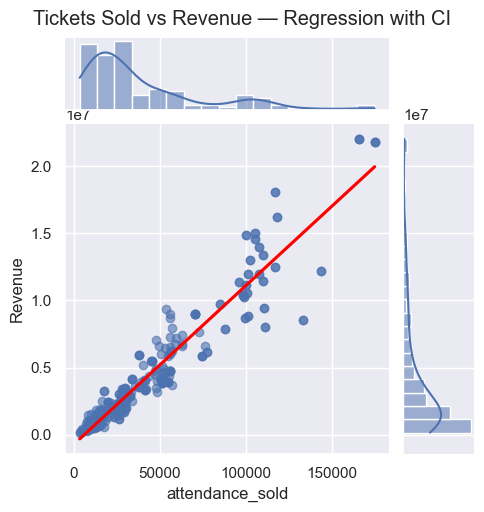

In [228]:
g = sns.jointplot(
    data=concert, x='attendance_sold', y='Revenue', 
    kind="reg", height=5, ratio=4, space=0.2, 
    joint_kws={"line_kws": {"linewidth":2}, "scatter_kws": {"alpha":0.6}, 'ci':0.95}, 
    line_kws={"color":"red"} 
    )
g.fig.suptitle("Tickets Sold vs Revenue — Regression with CI", y=1.02)

There is a strong positive linear relationship between the amount of concert tickets sold and ticket revenue where the amount of tickets sold (the independent variable) is increasing as the revenue (dependent variable) decreases. This suggests a positive correlation between variables. The red lines helps model this linear relationship. There are no strong outliers. 

### Distribution of Ticket Revenue by City in the USA

Using the package from plotly.express, two interactive plots were constructed that show clean visualizations for the data. Plotly is helpful in displaying charts because of its interactivity and aesthetically pleasing visuals. The first bar chart shows the distribution of Taylor Swift concert ticket revenue across cities in the United States. If you click on one of these bars, you can see the ticket revenue value for its respected city.

The data was filtered to only contain data for the United States and assigned to the dataframe `concert_us`. All NA values were dropped. This datframe is used for both plots. The specific columns `City` and `Revenue` were extracted from the dataframe and put in a new dictionary called `data`. The chart is shown below.

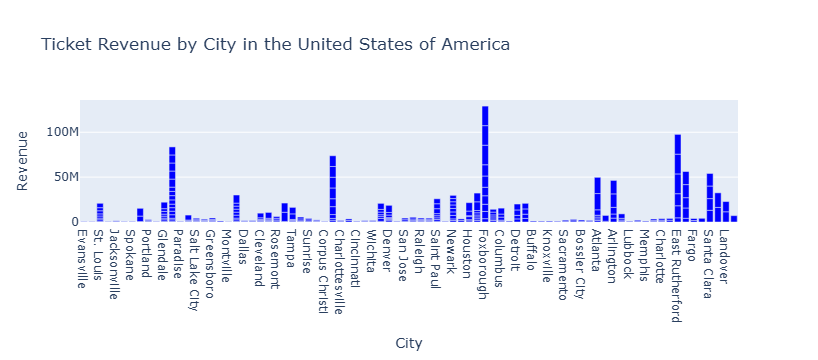

In [230]:
concert_us = concert[concert['Country'] == "United States of America"]
concert_us = concert_us.dropna()
data = {'City': concert_us['City'], 
        'Revenue': concert_us['Revenue']}
fig = px.bar(data, x='City', y='Revenue',
             color_discrete_sequence=['blue'],
             title='Ticket Revenue by City in the United States of America')
fig.show()


These bars show that the city with the highest concert ticket revenue was in Milwaukee, Wisconsin (21.7 million) and one of the lowest was in Jonesboro, Arkansas (340k). The bars very across sizes with many peaks. The highest peaks are in the more populated cities. Values range from about 300k to 22 million dollars. 

### Distribution of the Amount of Tickets Sold by City in the USA

The second bar chart shows the distribution of the amount of Taylor Swift concert tickets sold across cities in the United States. If you click on one of these bars, you can see the amount of tickets sold for its respected city.

The specific columns `City` and `attendance_sold` were extracted from the dataframe `concert_us` and put in a new dictionary called `data`. The chart is shown below.

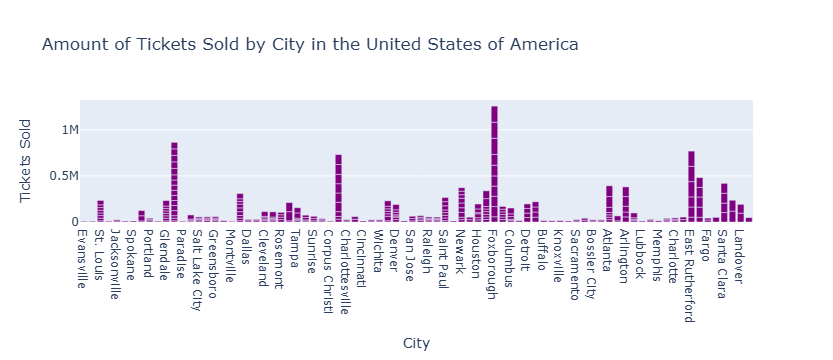

In [227]:
data = {'City': concert_us['City'], 
        'Tickets Sold': concert_us['attendance_sold']}
fig = px.bar(data, x='City', y='Tickets Sold', 
             color_discrete_sequence=['purple'],
             title='Amount of Tickets Sold by City in the United States of America')
fig.show()

The trends here are similar to the previous chart. These bars show that the city with the highest tickets sold was in Foxborough, Massachusetts (174k) and one of the lowest was in Evansville, Indiana (7463). The bars vary across sizes with many peaks. The highest peaks are in the more populated cities. Values range from about 7,000 to 174,000 tickets.

### Concert Ticket Revenue by Country

An interactive choropleth is displayed that shows Taylor Swift's ticket revenue by country. There are two layers: the choropleth and points. The choropleth displays the specific revenue value in each country while the green points give the longitude and latitude location of each country. Tooltips are incorporated where when you hover over a country, the country's name and revenue value show, and when you hover over a point, the associated longitude and latitude shows.

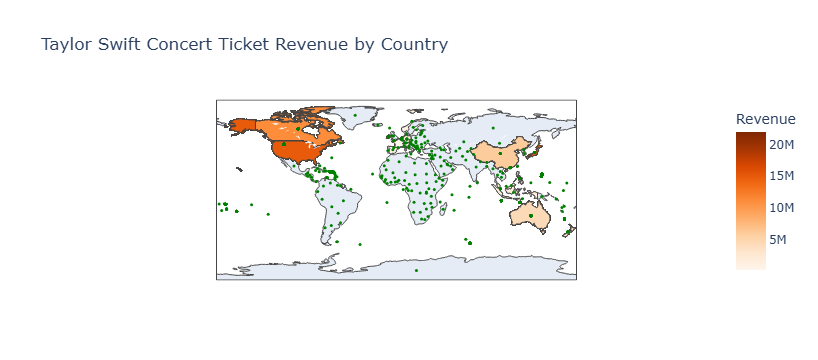

In [233]:
# interactive

fig = px.choropleth(
    merged,
    locations="Country",      
    color="Revenue",    # Column with values to color the map
    locationmode="country names",    
    color_continuous_scale="Oranges", 
    title="Taylor Swift Concert Ticket Revenue by Country"
)

merged["lon"] = merged.geometry.centroid.x
merged["lat"] = merged.geometry.centroid.y 

fig.add_scattergeo(
    lon=merged['lon'],
    lat=merged['lat'],
    mode='markers',
    marker=dict(size= 3, color='green'),
    name= '(Longitude, Latitude)',
 )

fig.show()

The lighter, whiter colors show lower values and the darker, oranger colors show higher values. The ticket revenue in Taylor Swift concerts vary. The map holds more intermediate colors (ranging a medium orange to a darker one) in North America. The lighter colors are in Europe, Asia, and Australia. The country with the highest ticket revenue is the United States. The green points show the exact longitude and latitude location of each country. Someone can easily access this geographical information due to this map.

An interactive map with plotly displays more information than a static choropleth and can be easier to read.

### Amount of Concert Tickets Sold by Country

An interactive choropleth is displayed that shows the amount of Taylor Swift concert tickets sold by country. There are two layers: the choropleth and points. The choropleth displays the specific ticket amount in each country while the green points give the longitude and latitude location of each country.

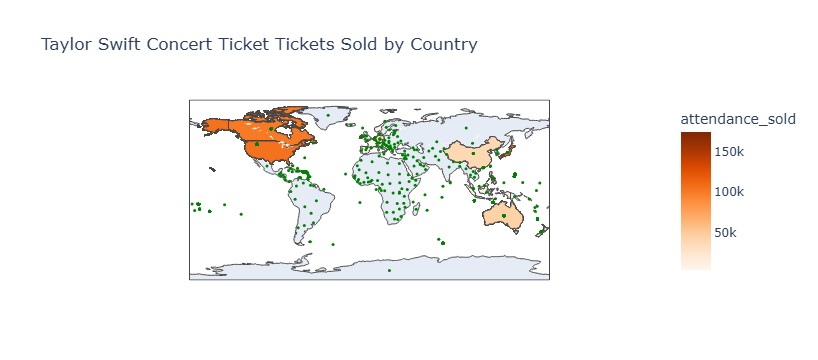

In [234]:
#  Create the choropleth map
fig = px.choropleth(
    concert,
    locations="Country",       
    color="attendance_sold",    
    locationmode="country names",    
    color_continuous_scale="Oranges", 
    title="Taylor Swift Concert Ticket Tickets Sold by Country"
)

merged["lon"] = merged.geometry.centroid.x
merged["lat"] = merged.geometry.centroid.y 

fig.add_scattergeo(
    lon=merged['lon'],
    lat=merged['lat'],
    mode='markers',
    marker=dict(size= 3, color='green'),
    name= '(Longitude, Latitude)',
 )

fig.show()

This map shows similar patterns to the one displaying ticket revenue. The lighter, whiter colors show lower values and the darker, oranger colors show higher values. The amount of concert tickets sold vary across countries. The map holds more intermediate colors (ranging in a medium orange) in North America. Canada and the United States have very similar values. The lighter colors are in Europe, Asia, and Australia. The green points show the exact longitude and latitude location of each country. Someone can easily access this geographical information due to this map.

## Classification of Lyrics and Albums

### Feature Importance (RF) Distinguishing Lyrics between Albums

Using Random Forest for feature importance helps one predict which input features have the most influence on the overall model. It is mainly useful for interpretation and feature selection, not evaluating performance.  Various `sklearn` packages had to be imported to use a vectorizer and conduct Random Forest classification. From the following plot, one can learn which phrases are most useful for splitting albums apart in classification.

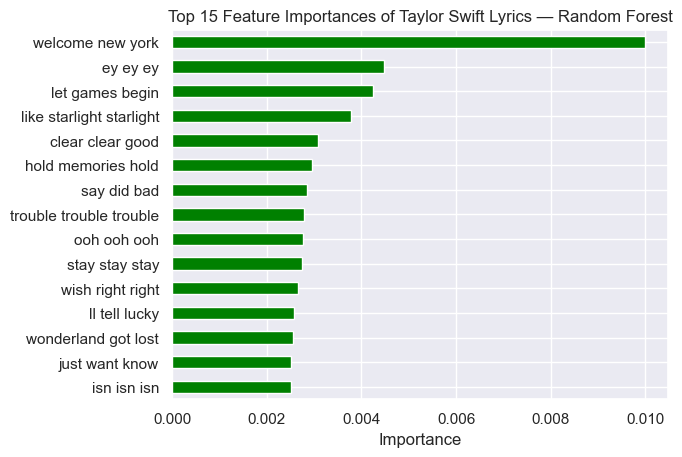

In [235]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(3, 3), max_features=5000)
X_train = vectorizer.fit_transform(train_df['lyric'])
X_test = vectorizer.transform(test_df['lyric'])
y_train = train_df['album']
y_test = test_df['album']

rf = RandomForestClassifier(n_estimators=150, random_state=42).fit(X_train, y_train)

feature_names = vectorizer.get_feature_names_out()

imp = pd.Series(rf.feature_importances_, index= feature_names).sort_values().tail(15)
imp.plot(kind='barh', color = "green")
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances of Taylor Swift Lyrics — Random Forest')
plt.show()

These phrases are the strongest indications that the model uses to differentiate lyrics between the six albums (*Taylor Swift, Fearless, Speak Now, Red, 1989, Reputation*). The higher the importance in the phrase, the more influence that word has on classifying between albums. Out of the top 15 feature importances with the `taylor_swift_lyrics.csv`, the phrase here with the highest importance is "welcome new york", from Swift's album *1989*, and the phrase with the lowest importance is "isn isn isn".

### Using Confusion Matrix to Assess Accuracy

A confusion matrix shows how a model performs by breaking down performance type. One can understand error types, not just overall accuracy. The following confusion matrix compares the lyrics within the six albums (`album`) with a Random Forest classifier.

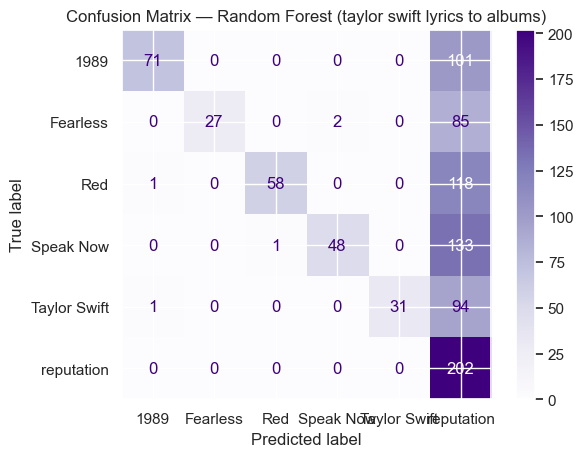

In [201]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Purples')

plt.title('Confusion Matrix — Random Forest (taylor swift lyrics to albums)')
plt.show()

The correct predictions lie on the diagonal values (71, 27, 58, 48, 31, 202). Most counts lie to the right of the matrix, not on the diagonal. This means that this model is heavily biased to predicting lyrics for the album, *Reputation*. The darker the square, the higher the predicted value. The high values on the right compared to the diagonal values show that the model has a hard time distinguishing the lyrics in *Fearless, Red, Speak Now, Taylor Swift,* and *1989* to *Reputation*. There are no major confusions with other albums in *Reputation*.

### Comparing Lyrics in *Fearless* to *Red*

Word clouds represent word frequency in text data. Words that are shown more frequently are bigger while words that are shown less frequency are smaller. The albums compared for this analysis are *Fearless* to *Red*. Each individual word cloud was created and joined into one word cloud, separated by color and a slider, to show comparison.


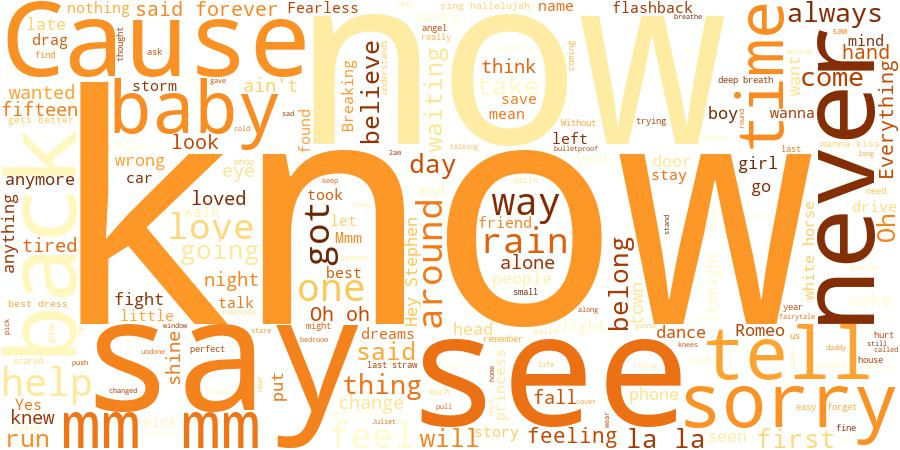
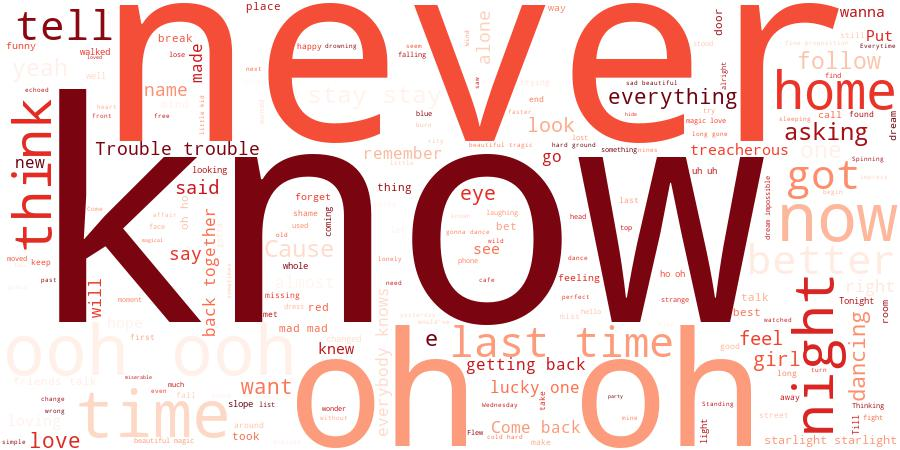

In [153]:
fearless_text = ' '.join(train_df[train_df.album=="Fearless"].lyric)
red_text = ' '.join(train_df[train_df.album=="Red"].lyric)
wc1 = WordCloud(width=900, height=450, background_color='white', colormap='YlOrBr').generate(fearless_text).to_image()
wc2 = WordCloud(width=900, height=450, background_color='white', colormap='Reds').generate(red_text).to_image()
img1 = wc1
img2 = wc2

compare(img1, img2, cmap="rocket", start_mode="horizontal", start_slider_pos=0.5, height=500, add_controls=False)

When comparing these word clouds, one can see that the word cloud on the left that represents text for *Fearless* is larger and denser than the word cloud on the right representing text for *Red*. This is likely due to the fact that the source text for *Fearless* has a higher volume of data, a lot more repetition in text, or has a more intense sentiment.

## Conclusion

This data story analyzes Taylor Swift’s concert and lyric data through various distributions, geographical mapping, machine learning, and natural language processing techniques. A GeoJSON file was read through and joined with Taylor Swift’s concert data to construct the maps.

A positive linear relationship was found between the amount of Taylor Swift’s concert tickets sold and the revenue from each city. This supports the statement that ticket sales are positively correlated with ticket revenue. A regression line, scatter plot, and 95% confidence interval was constructed to show this association. 

Two bar charts were constructed to show how concert ticket revenue and the amount of tickets sold were distributed across countries. Both charts were multimodal and had a large range in smallest to highest values. They are highly variable. Generally, the more populated cities had higher ticket revenue and ticket sales. This makes sense because the venues have more seats for people to buy and more people will attend, thus increasing revenue.

Two interactive choropleths were constructed to show Taylor Swift’s concert ticket revenue and sales within each country. Darker countries had high values, and lighter countries had smaller values. The higher values tended to concentrate in North America.

Using Random Forest to assess feature importance, the top 15 3-word lyrical phrases that distinguish Taylor Swift albums from one another were found. The Random Forest model is mainly useful for interpretation and feature selection, not evaluating performance, so a confusion matrix was created to see how the model performed. The correct predictions lie on the diagonal, but in this confusion matrix, most values lie to the right, near the *Reputation* album. The model has a hard time distinguishing the lyrics in *Fearless, Red, Speak Now, Taylor Swift,* and *1989* to *Reputation*.

Two word clouds were constructed and compared. The album *Fearless* had a larger and denser word cloud than *Red*. Many of the lyrics in *Fearless* distinguish it from other albums

Overall, the research questions for this project were answered with appropriate data visualization techniques and analyses.
